# FreeViz and SPCA: Quantitative Comparison

In this notebook, we compare FreeViz and SPCA classification accuracy
using 5-fold stratified cross-validation on three datasets.

- **FreeViz** is evaluated by training on the projected 2D space
  and predicting test labels via kNN with the best k selected from {1, 3, 5, 7}.
- **SPCA Classification** is evaluated by projecting test data
  with the learned loadings and classifying with the learned linear classifier.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from models import Freeviz
from models.spca_classification import SPCA_Classification
from utils import (
    load_zoo_data, load_mushroom_data, load_breast_cancer_data,
    scale_features, select_lambda
)

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/jasa/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [ ]:
def select_freeviz_k(E_train, C_train, n_dim, k_values=None):
    if k_values is None:
        k_values = [1, 3, 5, 7]

    # prepare training and test sets
    n = E_train.shape[0]
    indices = np.arange(n)
    rng = np.random.RandomState(42)
    rng.shuffle(indices)
    split = int(0.8 * n)
    inner_train, inner_val = indices[:split], indices[split:]
    E_inner_train, C_inner_train = E_train[inner_train], C_train[inner_train]
    E_inner_val, C_inner_val = E_train[inner_val], C_train[inner_val]

    # findd best k
    best_k = k_values[0]
    best_acc = -1.0
    for k in k_values:
        fv = Freeviz(n_dim).to(device)
        fv.train(E_inner_train, C_inner_train, print_loss=False)
        acc = fv.accuracy(E_inner_train, C_inner_train, E_inner_val, C_inner_val, k=k).item()
        print(f"  k={k}: val_acc={acc:.4f}")
        if acc > best_acc:
            best_acc = acc
            best_k = k

    print(f"  Best k={best_k} (val_acc={best_acc:.4f})")
    return best_k


def run_cv(E_raw, C, class_names, dataset_name, n_splits=5):
    E = scale_features(E_raw)
    C_np = C.cpu().numpy()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    freeviz_scores = []
    spca_scores = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(C_np, C_np)):
        E_train, E_test = E[train_idx], E[test_idx]
        C_train, C_test = C[train_idx], C[test_idx]

        # select best k for FreeViz
        print(f"--- {dataset_name} Fold {fold+1}: selecting FreeViz k ---")
        best_k = select_freeviz_k(E_train, C_train, E.shape[1])

        # train Freeviz with best k
        model = Freeviz(E.shape[1]).to(device)
        model.train(E_train, C_train, print_loss=False)
        acc_fv = model.accuracy(E_train, C_train, E_test, C_test, k=best_k).item()
        freeviz_scores.append(acc_fv)

        # select best lambda for SPCA (train with many lambdas, takes a while)
        E_train_f64 = E_train.to(torch.float64)
        best_lam = select_lambda(SPCA_Classification, E_train_f64, C_train, num_classes=len(class_names), steps=500)

        # train SPCA with best lambda
        train_mean = E_train.mean(dim=0)
        E_train_centered = E_train - train_mean
        model = SPCA_Classification(
            input_dim=E.shape[1], latent_dim=2,
            num_classes=len(class_names), lr=0.05
        ).to(device)
        model.train(E_train_centered, C_train,
                    lam=best_lam, steps=1000, classifier_epochs=50)

        # evaluate SPCA
        E_test_centered = E_test - train_mean
        logits = model(E_test_centered)
        preds = torch.argmax(logits, dim=1)
        acc_spca = (preds == C_test).float().mean().item()
        spca_scores.append(acc_spca)

        print(f"\n===== {dataset_name} Fold {fold+1}: "
              f"FreeViz(k={best_k})={acc_fv:.4f}, SPCA={acc_spca:.4f} =====\n")

    return freeviz_scores, spca_scores


def collect_results(name, fv_scores, spca_scores):
    return {
        "dataset": name,
        "fv_mean": np.mean(fv_scores),
        "spca_mean": np.mean(spca_scores),
    }

# ZOO dataset

In [4]:
E_zoo, C_zoo, names_zoo, feature_names_zoo, class_names_zoo = load_zoo_data(device)
fv_zoo, spca_zoo = run_cv(E_zoo, C_zoo, class_names_zoo, "ZOO")

/home/jasa/.local/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


--- ZOO Fold 1: selecting FreeViz k ---
  k=1: val_acc=0.7500
  k=3: val_acc=0.8125
  k=5: val_acc=0.6875
  k=7: val_acc=0.6875
  Best k=3 (val_acc=0.8125)
Step 0: loss = 1.8412, classifier loss = 1.8357
Step 10: loss = 1.1137, classifier loss = 1.1068
Step 20: loss = 0.8283, classifier loss = 0.8205
Step 30: loss = 0.7016, classifier loss = 0.6935
Step 40: loss = 0.6208, classifier loss = 0.6126
Step 50: loss = 0.5474, classifier loss = 0.5387
Step 60: loss = 0.4751, classifier loss = 0.4654
Step 70: loss = 0.4153, classifier loss = 0.4050
Step 80: loss = 0.3664, classifier loss = 0.3559
Step 90: loss = 0.3256, classifier loss = 0.3149
Step 100: loss = 0.2912, classifier loss = 0.2802
Step 110: loss = 0.2618, classifier loss = 0.2507
Step 120: loss = 0.2367, classifier loss = 0.2254
Step 130: loss = 0.2150, classifier loss = 0.2036
Step 140: loss = 0.1963, classifier loss = 0.1847
Step 150: loss = 0.1799, classifier loss = 0.1681
Step 160: loss = 0.1654, classifier loss = 0.1535
Step 

# MUSHROOM dataset

In [5]:
E_mush, C_mush, names_mush, feature_names_mush, class_names_mush = load_mushroom_data(device)
fv_mush, spca_mush = run_cv(E_mush, C_mush, class_names_mush, "MUSHROOM")

--- MUSHROOM Fold 1: selecting FreeViz k ---
  k=1: val_acc=0.8813
  k=3: val_acc=0.8625
  k=5: val_acc=0.8687
  k=7: val_acc=0.8750
  Best k=1 (val_acc=0.8813)
Step 0: loss = 1.1333, classifier loss = 0.6357
Step 10: loss = 0.8576, classifier loss = 0.3514
Step 20: loss = 0.7606, classifier loss = 0.2439
Step 30: loss = 0.7111, classifier loss = 0.1864
Step 40: loss = 0.6804, classifier loss = 0.1499
Step 50: loss = 0.6593, classifier loss = 0.1248
Step 60: loss = 0.6439, classifier loss = 0.1063
Step 70: loss = 0.6321, classifier loss = 0.0921
Step 80: loss = 0.6292, classifier loss = 0.0882
Step 90: loss = 0.6281, classifier loss = 0.0868
Step 100: loss = 0.6269, classifier loss = 0.0854
Step 110: loss = 0.6258, classifier loss = 0.0840
Step 120: loss = 0.6247, classifier loss = 0.0827
Step 130: loss = 0.6237, classifier loss = 0.0814
Step 140: loss = 0.6226, classifier loss = 0.0802
Step 150: loss = 0.6216, classifier loss = 0.0790
Step 160: loss = 0.6206, classifier loss = 0.0778


# BREAST CANCER dataset

In [6]:
E_bc, C_bc, names_bc, feature_names_bc, class_names_bc = load_breast_cancer_data(device)
fv_bc, spca_bc = run_cv(E_bc, C_bc, class_names_bc, "BREAST CANCER")

--- BREAST CANCER Fold 1: selecting FreeViz k ---
  k=1: val_acc=0.8352
  k=3: val_acc=0.8901
  k=5: val_acc=0.8681
  k=7: val_acc=0.8791
  Best k=3 (val_acc=0.8901)
Step 0: loss = 0.6642, classifier loss = 0.6632
Step 10: loss = 0.5123, classifier loss = 0.5109
Step 20: loss = 0.4311, classifier loss = 0.4297
Step 30: loss = 0.3749, classifier loss = 0.3735
Step 40: loss = 0.3338, classifier loss = 0.3323
Step 50: loss = 0.3024, classifier loss = 0.3008
Step 60: loss = 0.2776, classifier loss = 0.2760
Step 70: loss = 0.2576, classifier loss = 0.2560
Step 80: loss = 0.2411, classifier loss = 0.2394
Step 90: loss = 0.2273, classifier loss = 0.2256
Step 100: loss = 0.2157, classifier loss = 0.2140
Step 110: loss = 0.2110, classifier loss = 0.2092
Step 120: loss = 0.2098, classifier loss = 0.2080
Step 130: loss = 0.2086, classifier loss = 0.2068
Step 140: loss = 0.2075, classifier loss = 0.2057
Step 150: loss = 0.2063, classifier loss = 0.2046
Step 160: loss = 0.2052, classifier loss = 0.

# Summary

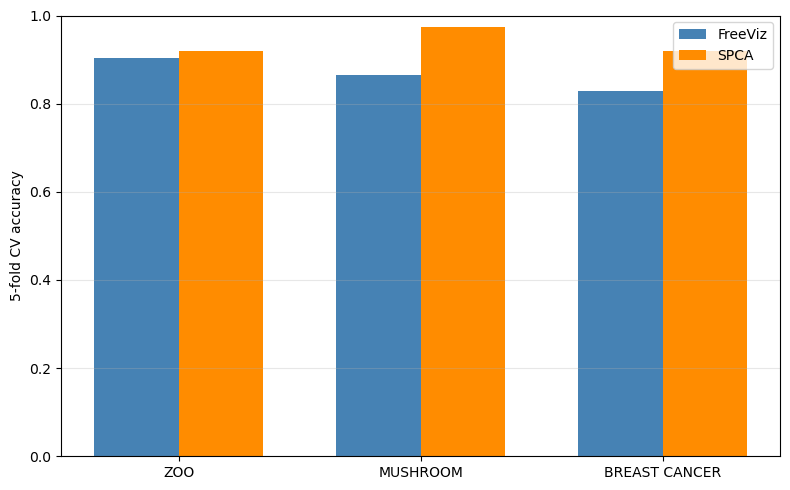

In [7]:
results = [
    collect_results("ZOO", fv_zoo, spca_zoo),
    collect_results("MUSHROOM", fv_mush, spca_mush),
    collect_results("BREAST CANCER", fv_bc, spca_bc),
]

datasets = [r["dataset"] for r in results]
x = np.arange(len(datasets))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, [r["fv_mean"] for r in results], w,
       label="FreeViz", color="steelblue")
ax.bar(x + w/2, [r["spca_mean"] for r in results], w,
       label="SPCA", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel("5-fold CV accuracy")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../final_vizualizations/compare_freeviz_spca_quantitative.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/compare_freeviz_spca_quantitative.png", format="png", bbox_inches="tight", dpi=150)
plt.show()